# Prepare a Public Dataset → Dry / Damp / Wet folders (Colab)

This notebook downloads a public road-surface dataset and **re-arranges it** into the layout your
`train_colab.ipynb` expects:

```
/content/data/
  train/Dry/*.jpg   train/Damp/*.jpg   train/Wet/*.jpg
  val/Dry/*.jpg     val/Damp/*.jpg     val/Wet/*.jpg
```

It supports three sources — run **one** of Section 2's options:

- **A. RSCD** via its Kaggle mirror (auto-download; needs a free Kaggle account).
- **B. RoadSaW** — download once from https://roadsaw.viscoda.com (usage agreement), put the zip in
  Google Drive, and point this at it.
- **C. Any folder** you already have.

The clever bit: instead of hard-coding a fragile folder structure, Section 3 **scans** whatever you
downloaded, reads each image's label from its path, and maps it to Dry/Damp/Wet. Edit one dictionary
to change the mapping.


## 1. Setup

In [1]:
import os, re, shutil, random, glob, collections, pathlib
random.seed(42)

RAW_DIR  = "/content/raw"      # where the downloaded dataset lands
OUT_DIR  = "/content/data"     # final Dry/Damp/Wet layout (train_colab.ipynb reads this)
os.makedirs(RAW_DIR, exist_ok=True)

# how many images per class to keep (RSCD has ~1M; you do NOT want them all in Colab)
PER_CLASS_CAP = 3000
VAL_FRACTION  = 0.15
print("ready")


ready


## 2. Get the data — run ONE option

---
### Option A — RSCD (Kaggle mirror, auto-download)

You need a free Kaggle account. Get your API token: kaggle.com → your avatar → *Settings* →
*Create New Token* → downloads `kaggle.json`. Run the cell, upload that file when prompted.


In [2]:
# --- Option A: RSCD from Kaggle ---
!pip -q install kaggle

from google.colab import files
print("Upload your kaggle.json (from kaggle.com > Settings > Create New Token):")
files.upload()  # pick kaggle.json

os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

# download + unzip the 1M RSCD mirror into RAW_DIR
!kaggle datasets download -d cristvollerei/rscd-dataset-1million -p {RAW_DIR} --unzip

print("\nDownloaded. Top-level contents of", RAW_DIR, ":")
print(os.listdir(RAW_DIR)[:20])


Upload your kaggle.json (from kaggle.com > Settings > Create New Token):


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/cristvollerei/rscd-dataset-1million
License(s): other
100% 13.9G/13.9G [02:57<00:00, 84.0MB/s]


Downloaded. Top-level contents of /content/raw :
['RSCD dataset-1million']


---
### Option B — RoadSaW (manual download once, then via Google Drive)

RoadSaW is behind a usage agreement, so it can't be auto-fetched. One-time steps:
1. Go to **https://roadsaw.viscoda.com**, accept the terms, download the dataset zip.
2. Upload that zip to your Google Drive (e.g. `MyDrive/roadsaw.zip`).
3. Run the cell below to mount Drive and unzip into `RAW_DIR`.


---
### Option C — I already have a folder of labelled images

Put your data anywhere under `RAW_DIR` (subfolders or filenames should contain the class words,
e.g. `.../dry/...`, `wet_123.jpg`, `damp/...`). Then just run Section 3.


## 3. Scan → map labels → build Dry/Damp/Wet folders

**Pick the dataset you downloaded** by setting `DATASET` below. This matters because the word "wet"
means *different things* in each dataset:

- **RSCD** friction words: `dry`→Dry, `wet`→**Damp** (RSCD "wet" = no standing water),
  `water`→**Wet** (standing water). Snow/ice skipped.
- **RoadSaW** wetness words: `dry`→Dry, `damp`→Damp, `wet`→**Wet**, `very_wet`→**Wet**.

If your own folder uses different words, set `DATASET="custom"` and edit `CUSTOM_RULES`.
Matching is on **whole path words only** (so "laundry" never counts as "dry").


In [3]:
DATASET = "rscd"          # <-- set to "rscd", "roadsaw", or "custom"

# words that mean "skip this image entirely" (winter conditions, irrelevant to racing)
SKIP_WORDS = {"snow", "ice", "slush", "snowy", "icy"}

# per-dataset rules: (word, target). Order = priority; first match wins, so the WETTER
# class is listed before the drier one where a dataset has overlapping words.
RSCD_RULES = [
    ("water", "Wet"),      # standing water  -> Wet
    ("wet",   "Damp"),     # RSCD "wet" (no standing water) -> Damp
    ("dry",   "Dry"),
]
ROADSAW_RULES = [
    ("verywet", "Wet"),
    ("wet",     "Wet"),    # RoadSaW "wet" IS fully wet
    ("damp",    "Damp"),
    ("dry",     "Dry"),
]
CUSTOM_RULES = [           # edit for your own folder names
    ("wet", "Wet"), ("damp", "Damp"), ("dry", "Dry"),
]
RULES = {"rscd": RSCD_RULES, "roadsaw": ROADSAW_RULES, "custom": CUSTOM_RULES}[DATASET]

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp"}

def label_for(path: str):
    """Return Dry/Damp/Wet for an image path, or None to skip. Whole-word matching only."""
    tokens = set(re.split(r"[^a-z]+", path.lower()))   # e.g. "very_wet/img.png" -> {very, wet, img, png}
    if tokens & SKIP_WORDS:
        return None
    # handle "very wet" / "very_wet" written as two adjacent words (RoadSaW)
    if DATASET == "roadsaw" and "very" in tokens and "wet" in tokens:
        return "Wet"
    for word, target in RULES:
        if word in tokens:            # whole-token match — "dry" won't match inside "laundry"
            return target
    return None

# gather candidate images grouped by target class
buckets = collections.defaultdict(list)
scanned = 0
for p in glob.glob(f"{RAW_DIR}/**/*", recursive=True):
    if pathlib.Path(p).suffix.lower() in IMG_EXT:
        scanned += 1
        lab = label_for(p)
        if lab:
            buckets[lab].append(p)

print(f"dataset preset: {DATASET}  |  scanned {scanned} images")
for c in ["Dry", "Damp", "Wet"]:
    print(f"  found {len(buckets[c]):>7} candidates for {c}")
if scanned and not any(buckets.values()):
    print("\n⚠ No labels matched. Print a few paths to see how labels are encoded,")
    print("  then set DATASET='custom' and edit CUSTOM_RULES:")
    for p in list(glob.glob(f"{RAW_DIR}/**/*", recursive=True))[:10]:
        print("   ", p)


dataset preset: rscd  |  scanned 1028301 images
  found  379269 candidates for Dry
  found  287050 candidates for Damp
  found  163727 candidates for Wet


In [4]:
# 2) balance (cap per class), split into train/val, copy into OUT_DIR
if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)

counts = {"train": collections.Counter(), "val": collections.Counter()}
for cls, paths in buckets.items():
    random.shuffle(paths)
    paths = paths[:PER_CLASS_CAP]                 # cap so Colab stays fast
    n_val = int(len(paths) * VAL_FRACTION)
    split_map = [("val", paths[:n_val]), ("train", paths[n_val:])]
    for split, plist in split_map:
        dst_dir = os.path.join(OUT_DIR, split, cls)
        os.makedirs(dst_dir, exist_ok=True)
        for i, src in enumerate(plist):
            ext = pathlib.Path(src).suffix.lower()
            shutil.copy(src, os.path.join(dst_dir, f"{cls}_{split}_{i}{ext}"))
            counts[split][cls] += 1

print("Done. Final dataset:")
for split in ["train", "val"]:
    print(f"  {split}: " + ", ".join(f"{c}={counts[split][c]}" for c in ["Dry","Damp","Wet"]))


Done. Final dataset:
  train: Dry=2550, Damp=2550, Wet=2550
  val: Dry=450, Damp=450, Wet=450


## 4. Sanity-check — look at a few images per class

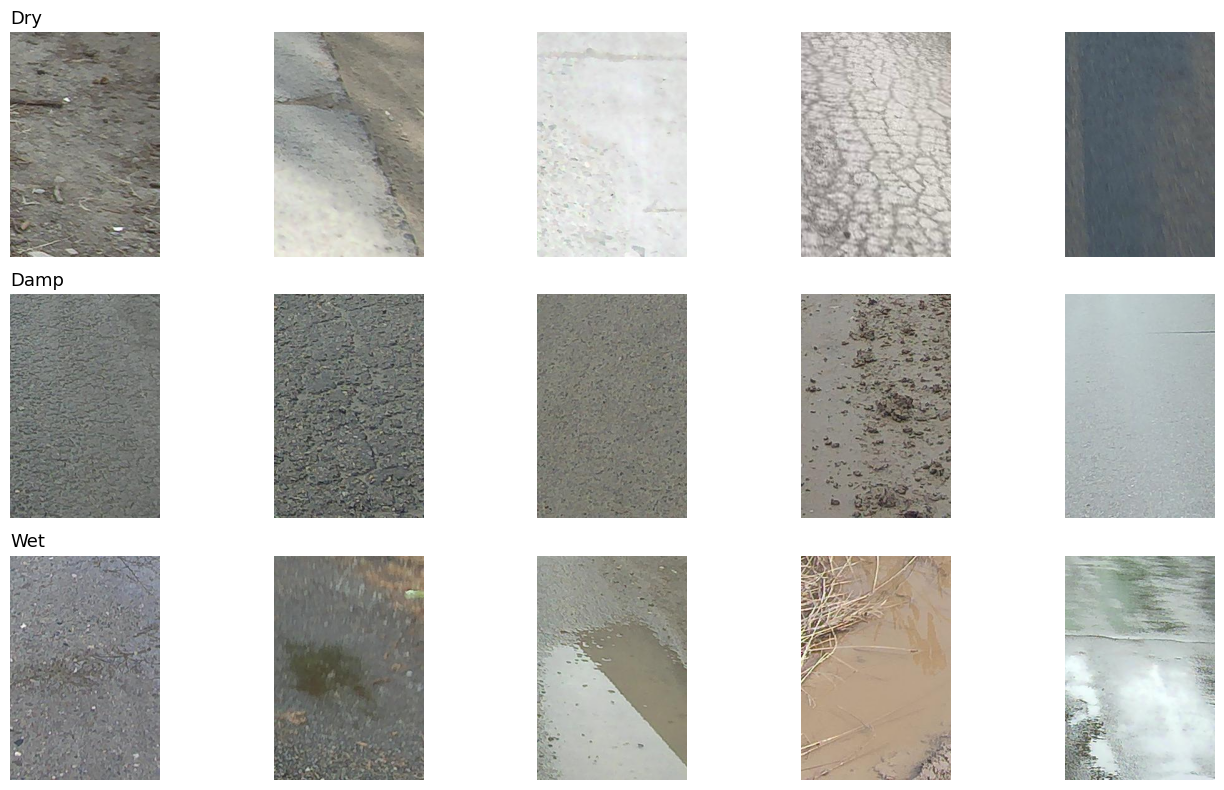

If the labels look wrong for a class, edit LABEL_RULES in Section 3 and re-run.


In [5]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(3, 5, figsize=(14, 8))
for row, cls in enumerate(["Dry", "Damp", "Wet"]):
    files_ = glob.glob(f"{OUT_DIR}/train/{cls}/*")[:5]
    for col in range(5):
        ax = axes[row][col]; ax.axis("off")
        if col < len(files_):
            ax.imshow(Image.open(files_[col]))
            if col == 0: ax.set_title(cls, loc="left", fontsize=13)
plt.tight_layout(); plt.show()
print("If the labels look wrong for a class, edit LABEL_RULES in Section 3 and re-run.")


In [6]:
# Colab already has torch + torchvision. We only need onnx tooling.
!pip -q install onnx onnxruntime

import os, json, time, shutil, random
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
print("torch", torch.__version__, "| cuda:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 83.1 MB/s eta 0:00:00
torch 2.11.0+cpu | cuda: False


In [7]:
# ---- Option C: synthetic smoke-test dataset (DELETE once you have real images) ----
from PIL import Image
import numpy as np

ROOT = "/content/data"
CLASSES = ["Dry", "Damp", "Wet"]
BRIGHT = {"Dry": 200, "Damp": 120, "Wet": 60}   # wetter = darker, crude but separable

def make(split, n):
    for c in CLASSES:
        d = f"{ROOT}/{split}/{c}"; os.makedirs(d, exist_ok=True)
        for i in range(n):
            base = BRIGHT[c] + np.random.randint(-25, 25)
            arr = np.clip(np.full((224,224,3), base) + np.random.randint(-15,15,(224,224,3)), 0,255).astype("uint8")
            if c == "Wet":  # specular highlights
                arr[np.random.randint(0,200):][:8, np.random.randint(0,180):][:60] = 255
            Image.fromarray(arr).save(f"{d}/{split}_{c}_{i}.jpg")

if not os.path.exists(f"{ROOT}/train"):
    make("train", 120); make("val", 30)
    print("synthetic dataset created at", ROOT)
else:
    print("dataset already present at", ROOT)


dataset already present at /content/data


In [8]:
IMG = 224
train_tf = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
])

train_ds = datasets.ImageFolder(f"{ROOT}/train", transform=train_tf)
val_ds   = datasets.ImageFolder(f"{ROOT}/val",   transform=val_tf)

# IMPORTANT: this is the class order the ONNX model will output. Save it for the app.
CLASS_NAMES = train_ds.classes
print("classes (output order):", CLASS_NAMES)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)


classes (output order): ['Damp', 'Dry', 'Wet']


In [9]:
model = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1)
in_f = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_f, len(CLASS_NAMES))
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 83.6MB/s]


In [10]:
EPOCHS = 8  # bump to 20-30 on a real dataset

def run_epoch(dl, train):
    model.train() if train else model.eval()
    tot, correct, loss_sum = 0, 0, 0.0
    with torch.set_grad_enabled(train):
        for x, y in dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            if train: optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward(); optimizer.step()
            loss_sum += loss.item() * x.size(0)
            correct  += (out.argmax(1) == y).sum().item()
            tot      += x.size(0)
    return loss_sum/tot, correct/tot

for ep in range(1, EPOCHS+1):
    tl, ta = run_epoch(train_dl, True)
    vl, va = run_epoch(val_dl, False)
    print(f"epoch {ep:2}/{EPOCHS}  train_acc={ta:.3f}  val_acc={va:.3f}")


epoch  1/8  train_acc=0.694  val_acc=0.789
epoch  2/8  train_acc=0.792  val_acc=0.819
epoch  3/8  train_acc=0.836  val_acc=0.839
epoch  4/8  train_acc=0.857  val_acc=0.845
epoch  5/8  train_acc=0.874  val_acc=0.854
epoch  6/8  train_acc=0.883  val_acc=0.856
epoch  7/8  train_acc=0.895  val_acc=0.868
epoch  8/8  train_acc=0.908  val_acc=0.867


In [11]:
import numpy as np
model.eval()
n = len(CLASS_NAMES); cm = np.zeros((n,n), int)
with torch.no_grad():
    for x,y in val_dl:
        p = model(x.to(DEVICE)).argmax(1).cpu().numpy()
        for t,pr in zip(y.numpy(), p): cm[t,pr]+=1
print("rows=true, cols=pred |", CLASS_NAMES)
print(cm)


rows=true, cols=pred | ['Damp', 'Dry', 'Wet']
[[376  47  27]
 [ 37 407   6]
 [ 47  15 388]]


In [12]:
model.eval().cpu()
dummy = torch.randn(1, 3, IMG, IMG)

# NOTE: recent PyTorch (2.9+) switched torch.onnx.export's default to the new "dynamo"
# exporter, which needs a separate `onnxscript` package that isn't installed by default —
# that's the "ModuleNotFoundError: No module named onnxscript" some people hit here. We force
# the classic TorchScript-based exporter (dynamo=False), which handles a plain CNN like
# MobileNetV3 fine and needs no extra install. Falls back gracefully on older torch too.
def _export():
    torch.onnx.export(
        model, dummy, "model.onnx",
        input_names=["input"], output_names=["logits"],
        dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
        opset_version=13,
        dynamo=False,
    )

try:
    _export()
except TypeError:
    # older torch that predates the `dynamo` kwarg entirely -- just export normally
    torch.onnx.export(
        model, dummy, "model.onnx",
        input_names=["input"], output_names=["logits"],
        dynamic_axes={"input": {0: "batch"}, "logits": {0: "batch"}},
        opset_version=13,
    )
except ModuleNotFoundError:
    # unexpected: dynamo path still got triggered -- install onnxscript and retry once
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "onnxscript"], check=True)
    _export()

with open("class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)
print("wrote model.onnx and class_names.json")

# sanity-check the exported model runs in onnxruntime
import onnxruntime as ort, numpy as np
sess = ort.InferenceSession("model.onnx", providers=["CPUExecutionProvider"])
out = sess.run(None, {"input": dummy.numpy()})[0]
print("onnx output shape:", out.shape, "->", CLASS_NAMES)


/tmp/ipykernel_3594/3029669179.py:10: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


wrote model.onnx and class_names.json
onnx output shape: (1, 3) -> ['Damp', 'Dry', 'Wet']


In [13]:
from google.colab import files
files.download("model.onnx")
files.download("class_names.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Next step

`/content/data` is now ready. Open **`train_colab.ipynb`**, and in its Section 2 **skip the synthetic
cell** (you now have real data at `/content/data`). Run the rest to fine-tune MobileNetV3 and export
`model.onnx`.

> Licences: RSCD is CC BY-NC (non-commercial). RoadSaW has its own usage terms. Fine for a
> student/hackathon project; check the terms before any commercial use.
